# Unified Experiment Notebook: Subsampling & Margin Control

## Linear Perception Task — Single-Shortcut (E1–E6) & Two-Shortcut (E7)

**Paper:** *Subsampling and Margin Control: Overparameterisation as the Central Failure Mode in Shortcut Mitigation*

**Design:** Each experiment cell checks Google Drive for existing results. If found, it loads them; otherwise it trains from scratch. Hit **Runtime → Run all** for a complete run.

### Experiment Index
| # | Name | Key Question |
|---|------|-------------|
| E1 | Baseline | Reproduce Puli et al. + GB-Down |
| E2 | Random subsampling grid | WGA vs ratio — phase transition at d/n=1 |
| E3 | Group-balanced analysis | GB-Down across ρ (complementary vs antagonistic) |
| E4 | Dataset size ablation | Confirm d/n=1 as sharp boundary |
| E5 | Overfitting analysis | Bias vs variance decomposition |
| E6 | B-scaling | MARG-CTRL invariance to shortcut magnitude |
| E7a–e | Two-shortcut experiments | Multiple shortcuts eliminated simultaneously |

### Figure Index
| Fig | Source | Content |
|-----|--------|---------|
| 1 | E2 | Phase transition: WGA vs d/n |
| 2 | E5 | Margin std + gen gap vs d/n |
| 3 | E6 | WGA vs B (Full and GB-Down) |
| 4 | E7d | Two-shortcut SR and WGA vs n |
| 5 | E3 | GB-Down complementary vs antagonistic |
| 6 | E4 | SD WGA heatmap (condition × n) |
| 7 | E7e | Two-shortcut strategy comparison |
| 8 | E1 | Baseline bar chart |

## Section 0: Setup

In [ ]:
# ============================================================
# Setup — Install deps, mount Drive, create directories
# ============================================================
import subprocess, sys

for pkg in ['seaborn', 'pandas']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/shortcut_experiments'
    IN_COLAB = True
except ImportError:
    DRIVE_ROOT = './shortcut_experiments'
    IN_COLAB = False

import os
for d in ['csv', 'checkpoints', 'logs', 'figures']:
    os.makedirs(f'{DRIVE_ROOT}/{d}', exist_ok=True)
print(f'Drive root: {DRIVE_ROOT}')
print(f'Running in Colab: {IN_COLAB}')

Mounted at /content/drive
Drive root: /content/drive/MyDrive/shortcut_experiments
Running in Colab: True


## Section 1: Infrastructure

In [ ]:
# ============================================================
# Imports and global parameters
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import time, json, os, warnings
from collections import OrderedDict
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── DGP parameters ──
D       = 300
B       = 10
B1, B2  = 10, 10
RHO     = 0.9
N_TRAIN = 1000
N_TEST  = 2000
RHO1_TRAIN, RHO2_TRAIN = 0.9, 0.7

# ── Training ──
EPOCHS  = 10000
LR      = 0.01

# ── Derived ──
N_CRIT_SINGLE = D / (2 * (1 - RHO))
N_CRIT_Z1     = D / (2 * (1 - RHO1_TRAIN))
N_CRIT_Z2     = D / (2 * (1 - RHO2_TRAIN))

# ── Paths ──
CSV_DIR  = Path(f'{DRIVE_ROOT}/csv')
SAVE_DIR = Path(f'{DRIVE_ROOT}/figures')

print(f'Device: {device}')
print(f'DGP: d={D}, B={B}, rho={RHO}, n_train={N_TRAIN}')
print(f'Two-shortcut: B1={B1}, B2={B2}, rho1={RHO1_TRAIN}, rho2={RHO2_TRAIN}')

Device: cuda
DGP: d=300, B=10, rho=0.9, n_train=1000
Two-shortcut: B1=10, B2=10, rho1=0.9, rho2=0.7


In [ ]:
# ============================================================
# Data generating processes
# ============================================================

def generate_linear_data(n, d, rho, B, seed=None):
    rng = np.random.RandomState(seed)
    y = rng.choice([-1.0, 1.0], size=n)
    flip = rng.binomial(1, 1 - rho, size=n)
    z = y * (1 - 2 * flip)
    delta = rng.randn(n, d - 2)
    X = np.column_stack([B * z, y, delta]).astype(np.float32)
    groups = (y != z).astype(int)
    return X, y.astype(np.float32), z.astype(np.float32), groups

def generate_two_shortcut_data(n, d, rho1, rho2, B1, B2, seed=None):
    rng = np.random.RandomState(seed)
    y = rng.choice([-1.0, 1.0], size=n)
    flip1 = rng.binomial(1, 1 - rho1, size=n)
    flip2 = rng.binomial(1, 1 - rho2, size=n)
    z1 = y * (1 - 2 * flip1)
    z2 = y * (1 - 2 * flip2)
    delta = rng.randn(n, d - 3)
    X = np.column_stack([B1 * z1, B2 * z2, y, delta]).astype(np.float32)
    agree1, agree2 = (y == z1), (y == z2)
    groups = np.zeros(n, dtype=int)
    groups[agree1 & agree2]   = 0
    groups[agree1 & ~agree2]  = 1
    groups[~agree1 & agree2]  = 2
    groups[~agree1 & ~agree2] = 3
    return X, y.astype(np.float32), z1.astype(np.float32), z2.astype(np.float32), groups

# ============================================================
# Loss functions
# ============================================================

class LogLoss(nn.Module):
    def forward(self, logits, targets):
        return torch.log(1 + torch.exp(-targets * logits.squeeze())).mean()

class SigmaDampedLoss(nn.Module):
    def __init__(self, temperature=2.0):
        super().__init__()
        self.T = temperature
    def forward(self, logits, targets):
        f = logits.squeeze()
        damped = targets * (1 - torch.sigmoid(targets * f / self.T)) * f
        return torch.log(1 + torch.exp(-damped)).mean()

class SpectralDecoupling(nn.Module):
    def __init__(self, lam=0.1):
        super().__init__()
        self.lam = lam
    def forward(self, logits, targets):
        f = logits.squeeze()
        return torch.log(1 + torch.exp(-targets * f)).mean() + self.lam * (f ** 2).mean()

class MargLogLoss(nn.Module):
    def __init__(self, lam=0.5):
        super().__init__()
        self.lam = lam
    def forward(self, logits, targets):
        f = logits.squeeze()
        return torch.log(1 + torch.exp(-targets * f)).mean() + self.lam * torch.log(1 + f ** 2).mean()

LOSS_FNS = OrderedDict([
    ('ERM',        lambda: LogLoss()),
    ('sigma-Damp', lambda: SigmaDampedLoss(temperature=2.0)),
    ('SD',         lambda: SpectralDecoupling(lam=0.1)),
    ('Marg-Log',   lambda: MargLogLoss(lam=0.5)),
])
LOSS_FNS_CORE = OrderedDict([
    ('ERM',      LOSS_FNS['ERM']),
    ('SD',       LOSS_FNS['SD']),
    ('Marg-Log', LOSS_FNS['Marg-Log']),
])

# ============================================================
# Model and training
# ============================================================

class LinearModel(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.linear = nn.Linear(d, 1, bias=False)
        nn.init.normal_(self.linear.weight, std=0.01)
    def forward(self, x):
        return self.linear(x)
    def get_weights(self):
        return self.linear.weight.data.cpu().numpy().flatten()

def train_model(model, X_train, y_train, loss_fn, epochs=EPOCHS, lr=LR):
    model = model.to(device)
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        optimizer.step()
    return model

# ============================================================
# Evaluation
# ============================================================

def evaluate_single(model, X, y, groups, B_val):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    preds = np.sign(logits); preds[preds == 0] = 1
    margins = y * logits
    idx_s, idx_l = groups == 0, groups == 1
    acc = float(np.mean(preds == y))
    acc_s = float(np.mean(preds[idx_s] == y[idx_s])) if idx_s.sum() > 0 else np.nan
    acc_l = float(np.mean(preds[idx_l] == y[idx_l])) if idx_l.sum() > 0 else np.nan
    wga = min(v for v in [acc_s, acc_l] if not np.isnan(v))
    w = model.get_weights()
    B_wz = B_val * w[0]; sr = abs(B_wz) / (abs(w[1]) + 1e-10)
    margin_gap = abs(float(margins[idx_s].mean()) - float(margins[idx_l].mean())) if idx_s.sum() > 0 and idx_l.sum() > 0 else np.nan
    return {
        'acc': acc, 'acc_shortcut': acc_s, 'acc_leftover': acc_l, 'wga': wga,
        'B_wz': float(B_wz), 'wy': float(w[1]), 'shortcut_ratio': float(sr),
        'shortcut_dominates': int(sr > 1.0), 'w_noise_norm': float(np.linalg.norm(w[2:])),
        'margin_gap': margin_gap, 'margin_std': float(np.std(margins)),
    }

def evaluate_two_shortcut(model, X, y, z1, z2, groups, B1_val, B2_val):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    preds = np.sign(logits); preds[preds == 0] = 1
    margins = y * logits
    acc = float(np.mean(preds == y))
    acc_g, margin_g = {}, {}
    for g in range(4):
        idx = groups == g
        acc_g[g] = float(np.mean(preds[idx] == y[idx])) if idx.sum() > 0 else np.nan
        margin_g[g] = float(margins[idx].mean()) if idx.sum() > 0 else np.nan
    valid = [v for v in acc_g.values() if not np.isnan(v)]
    wga = min(valid) if valid else np.nan
    mv = [v for v in margin_g.values() if not np.isnan(v)]
    margin_gap = max(mv) - min(mv) if len(mv) > 1 else np.nan
    w = model.get_weights()
    eps = 1e-10
    SR1 = abs(B1_val * w[0]) / (abs(w[2]) + eps)
    SR2 = abs(B2_val * w[1]) / (abs(w[2]) + eps)
    return {
        'acc': acc, **{f'acc_g{g}': acc_g[g] for g in range(4)}, 'wga': wga,
        'w_z1': float(w[0]), 'w_z2': float(w[1]), 'w_y': float(w[2]),
        'B1_wz1': float(B1_val*w[0]), 'B2_wz2': float(B2_val*w[1]),
        'SR1': float(SR1), 'SR2': float(SR2),
        'shortcut1_dominates': int(SR1 > 1.0), 'shortcut2_dominates': int(SR2 > 1.0),
        'w_noise_norm': float(np.linalg.norm(w[3:])),
        'margin_gap': margin_gap,
        **{f'margin_g{g}': margin_g[g] for g in range(4)},
    }

# ============================================================
# Subsampling strategies
# ============================================================

def random_subsample(X, y, z, groups, ratio, seed=None):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(y), max(int(len(y) * ratio), 2), replace=False)
    return X[idx], y[idx], z[idx], groups[idx]

def group_balanced_downsample(X, y, z, groups, seed=None):
    rng = np.random.RandomState(seed)
    idx_s, idx_l = np.where(groups == 0)[0], np.where(groups == 1)[0]
    n_min = min(len(idx_s), len(idx_l))
    idx = np.concatenate([rng.choice(idx_s, n_min, replace=False), rng.choice(idx_l, n_min, replace=False)])
    rng.shuffle(idx)
    return X[idx], y[idx], z[idx], groups[idx]

def random_subsample_to_size(X, y, z, groups, target_n, seed=None):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(y), min(target_n, len(y)), replace=False)
    return X[idx], y[idx], z[idx], groups[idx]

def group_balanced_oversample(X, y, z, groups, seed=None):
    rng = np.random.RandomState(seed)
    idx_s, idx_l = np.where(groups == 0)[0], np.where(groups == 1)[0]
    n_max = max(len(idx_s), len(idx_l))
    if len(idx_s) < n_max: idx_s = rng.choice(idx_s, n_max, replace=True)
    if len(idx_l) < n_max: idx_l = rng.choice(idx_l, n_max, replace=True)
    idx = np.concatenate([idx_s, idx_l]); rng.shuffle(idx)
    return X[idx], y[idx], z[idx], groups[idx]

def balance_shortcut1(X, y, z1, z2, groups, seed=None):
    rng = np.random.RandomState(seed)
    a, d = np.where(np.isin(groups, [0,1]))[0], np.where(np.isin(groups, [2,3]))[0]
    n = min(len(a), len(d))
    idx = np.concatenate([rng.choice(a, n, replace=False), rng.choice(d, n, replace=False)]); rng.shuffle(idx)
    return X[idx], y[idx], z1[idx], z2[idx], groups[idx]

def balance_shortcut2(X, y, z1, z2, groups, seed=None):
    rng = np.random.RandomState(seed)
    a, d = np.where(np.isin(groups, [0,2]))[0], np.where(np.isin(groups, [1,3]))[0]
    n = min(len(a), len(d))
    idx = np.concatenate([rng.choice(a, n, replace=False), rng.choice(d, n, replace=False)]); rng.shuffle(idx)
    return X[idx], y[idx], z1[idx], z2[idx], groups[idx]

def balance_four_groups(X, y, z1, z2, groups, seed=None):
    rng = np.random.RandomState(seed)
    n_min = min((groups == g).sum() for g in range(4))
    idx = np.concatenate([rng.choice(np.where(groups == g)[0], n_min, replace=False) for g in range(4)]); rng.shuffle(idx)
    return X[idx], y[idx], z1[idx], z2[idx], groups[idx]

# ============================================================
# Utilities
# ============================================================

def save_csv(df, name):
    path = f'{DRIVE_ROOT}/csv/{name}'
    df.to_csv(path, index=False)
    print(f'  Saved {path} ({len(df)} rows)')

def log_experiment(exp_name, message):
    path = f'{DRIVE_ROOT}/logs/experiment_log.txt'
    with open(path, 'a') as f:
        f.write(f'[{time.strftime("%Y-%m-%d %H:%M:%S")}] {exp_name}: {message}\n')

def try_load(name, expected_min_rows=0):
    path = CSV_DIR / name
    if path.exists():
        df = pd.read_csv(path)
        if len(df) >= expected_min_rows:
            print(f'  Loaded {name} ({len(df)} rows)')
            return df
    return None

def run_single_shortcut_experiment(config, loss_registry=None):
    if loss_registry is None: loss_registry = LOSS_FNS_CORE
    results = []; d = config['d']; B_val = config['B']
    for seed in config['seeds']:
        X_tr, y_tr, z_tr, g_tr = generate_linear_data(config['n'], d, config['rho_train'], B_val, seed=seed*500)
        X_te, y_te, z_te, g_te = generate_linear_data(N_TEST, d, config['rho_test'], B_val, seed=seed*500+1)
        for cond_name, sub_fn, sub_args in config['conditions']:
            Xc, yc, zc, gc = (X_tr, y_tr, z_tr, g_tr) if sub_fn is None else sub_fn(X_tr, y_tr, z_tr, g_tr, **sub_args, seed=seed)
            n_sub = len(yc); leftover_frac = float(gc.mean())
            for method_name, loss_factory in loss_registry.items():
                torch.manual_seed(seed*1000 + hash(method_name) % 1000)
                model = train_model(LinearModel(d), Xc, yc, loss_factory(), epochs=config.get('epochs', EPOCHS), lr=config.get('lr', LR))
                test_m = evaluate_single(model, X_te, y_te, g_te, B_val)
                train_m = evaluate_single(model, Xc, yc, gc, B_val)
                results.append({
                    'method': method_name, 'condition': cond_name, 'seed': seed,
                    'n_original': config['n'], 'n_train': n_sub, 'd': d, 'd_over_n': d/n_sub,
                    'B': B_val, 'rho_train': config['rho_train'], 'rho_test': config['rho_test'],
                    'leftover_frac': leftover_frac,
                    'test_acc': test_m['acc'], 'test_wga': test_m['wga'],
                    'test_acc_shortcut': test_m['acc_shortcut'], 'test_acc_leftover': test_m['acc_leftover'],
                    'test_margin_gap': test_m['margin_gap'],
                    'B_wz': test_m['B_wz'], 'wy': test_m['wy'],
                    'shortcut_ratio': test_m['shortcut_ratio'], 'shortcut_dominates': test_m['shortcut_dominates'],
                    'w_noise_norm': test_m['w_noise_norm'],
                    'train_acc': train_m['acc'], 'train_margin_std': train_m['margin_std'],
                    'gen_gap': train_m['acc'] - test_m['acc'],
                })
    return results

def run_two_shortcut_experiment(n_train, strategies, seeds, loss_registry=None,
                                d=D, rho1=RHO1_TRAIN, rho2=RHO2_TRAIN, b1=B1, b2=B2, epochs=EPOCHS, lr=LR):
    if loss_registry is None: loss_registry = LOSS_FNS_CORE
    results = []
    for seed in seeds:
        X_tr, y_tr, z1_tr, z2_tr, g_tr = generate_two_shortcut_data(n_train, d, rho1, rho2, b1, b2, seed=seed*100)
        X_te, y_te, z1_te, z2_te, g_te = generate_two_shortcut_data(N_TEST, d, 1-rho1, 1-rho2, b1, b2, seed=seed*100+1)
        X_z1c, y_z1c, z1_z1c, z2_z1c, g_z1c = generate_two_shortcut_data(N_TEST, d, 1-rho1, rho2, b1, b2, seed=seed*100+2)
        X_z2c, y_z2c, z1_z2c, z2_z2c, g_z2c = generate_two_shortcut_data(N_TEST, d, rho1, 1-rho2, b1, b2, seed=seed*100+3)
        for strat_name, sub_fn in strategies.items():
            Xs, ys, z1s, z2s, gs = (X_tr, y_tr, z1_tr, z2_tr, g_tr) if sub_fn is None else sub_fn(X_tr, y_tr, z1_tr, z2_tr, g_tr, seed=seed)
            n_sub = len(ys)
            for method_name, loss_factory in loss_registry.items():
                torch.manual_seed(seed*1000 + hash(method_name) % 1000)
                model = train_model(LinearModel(d), Xs, ys, loss_factory(), epochs=epochs, lr=lr)
                test_m = evaluate_two_shortcut(model, X_te, y_te, z1_te, z2_te, g_te, b1, b2)
                z1ch_m = evaluate_two_shortcut(model, X_z1c, y_z1c, z1_z1c, z2_z1c, g_z1c, b1, b2)
                z2ch_m = evaluate_two_shortcut(model, X_z2c, y_z2c, z1_z2c, z2_z2c, g_z2c, b1, b2)
                train_m = evaluate_two_shortcut(model, Xs, ys, z1s, z2s, gs, b1, b2)
                row = {
                    'method': method_name, 'strategy': strat_name, 'seed': seed,
                    'n_original': n_train, 'n_train': n_sub, 'd': d, 'd_over_n': d/n_sub,
                    'B1': b1, 'B2': b2, 'rho1': rho1, 'rho2': rho2,
                    'k1_frac': float(np.isin(gs,[2,3]).mean()), 'k2_frac': float(np.isin(gs,[1,3]).mean()),
                    'w_z1': test_m['w_z1'], 'w_z2': test_m['w_z2'], 'w_y': test_m['w_y'],
                    'B1_wz1': test_m['B1_wz1'], 'B2_wz2': test_m['B2_wz2'],
                    'SR1': test_m['SR1'], 'SR2': test_m['SR2'],
                    'shortcut1_dominates': test_m['shortcut1_dominates'],
                    'shortcut2_dominates': test_m['shortcut2_dominates'],
                    'w_noise_norm': test_m['w_noise_norm'],
                }
                for prefix, m in [('test', test_m), ('z1ch', z1ch_m), ('z2ch', z2ch_m)]:
                    row[f'{prefix}_acc'] = m['acc']; row[f'{prefix}_wga'] = m['wga']
                    for g in range(4): row[f'{prefix}_acc_g{g}'] = m[f'acc_g{g}']
                    row[f'{prefix}_margin_gap'] = m['margin_gap']
                row['train_acc'] = train_m['acc']; row['gen_gap'] = train_m['acc'] - test_m['acc']
                results.append(row)
    return results

print('All infrastructure ready.')

All infrastructure ready.


---
# Part A: Single-Shortcut Experiments (E1–E6)

## E1: Baseline Reproduction

In [ ]:
t0 = time.time()
df_e1 = try_load('results_e1_baseline.csv', 27)
if df_e1 is None:
    e1_config = {
        'n': N_TRAIN, 'd': D, 'rho_train': RHO, 'rho_test': 1 - RHO,
        'B': B, 'seeds': list(range(3)),
        'conditions': [('Full', None, {}), ('GB-Down', group_balanced_downsample, {}), ('GB-Over', group_balanced_oversample, {})],
    }
    df_e1 = pd.DataFrame(run_single_shortcut_experiment(e1_config))
    save_csv(df_e1, 'results_e1_baseline.csv')
    print(f'  E1 trained in {time.time()-t0:.0f}s')
agg = df_e1.groupby(['condition','method']).agg(wga=('test_wga','mean'),sr=('shortcut_ratio','mean'),n_train=('n_train','mean'),d_over_n=('d_over_n','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e1_baseline.csv (27 rows)
condition   method   wga    sr  n_train  d_over_n
     Full      ERM 0.400 1.749 1000.000     0.300
     Full Marg-Log 1.000 0.004 1000.000     0.300
     Full       SD 1.000 0.002 1000.000     0.300
  GB-Down      ERM 0.500 0.620  204.667     1.491
  GB-Down Marg-Log 0.523 0.173  204.667     1.491
  GB-Down       SD 0.508 0.390  204.667     1.491
  GB-Over      ERM 0.365 2.269 1795.333     0.167
  GB-Over Marg-Log 1.000 0.005 1795.333     0.167
  GB-Over       SD 1.000 0.001 1795.333     0.167


## E2: Random Subsampling Grid (with d/n=1.0 point)

In [ ]:
t0 = time.time()
df_e2 = try_load('results_e2_random_grid.csv', 330)  # 7 ratios x 4 rho x 4 methods x 3 seeds = 336
if df_e2 is None:
    RATIOS = [0.1, 0.25, 0.30, 0.35, 0.5, 0.75, 1.0]  # includes d/n=1.0 and 0.857
    RHOS = [0.7, 0.8, 0.9, 0.95]; SEEDS = list(range(3))
    e2_results = []
    for rho in RHOS:
        for ratio in RATIOS:
            config = {'n': N_TRAIN, 'd': D, 'rho_train': rho, 'rho_test': 1-rho, 'B': B, 'seeds': SEEDS,
                      'conditions': [(f'r={ratio}', random_subsample, {'ratio': ratio})]}
            for r in (res := run_single_shortcut_experiment(config, loss_registry=LOSS_FNS)):
                r['ratio'] = ratio; r['rho'] = rho
            e2_results.extend(res)
    df_e2 = pd.DataFrame(e2_results)
    save_csv(df_e2, 'results_e2_random_grid.csv')
    print(f'  E2 trained in {time.time()-t0:.0f}s')
agg = df_e2.groupby(['ratio','method']).agg(wga=('test_wga','mean'),sr=('shortcut_ratio','mean'),d_over_n=('d_over_n','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e2_random_grid.csv (336 rows)
 ratio     method   wga     sr  d_over_n
 0.100        ERM 0.311  8.267     3.000
 0.100   Marg-Log 0.371  5.303     3.000
 0.100         SD 0.317 10.535     3.000
 0.100 sigma-Damp 0.304  8.891     3.000
 0.250        ERM 0.320  6.748     1.200
 0.250   Marg-Log 0.408  2.601     1.200
 0.250         SD 0.397  3.588     1.200
 0.250 sigma-Damp 0.389  4.186     1.200
 0.300        ERM 0.308  6.431     1.000
 0.300   Marg-Log 0.928  0.051     1.000
 0.300         SD 0.871  0.075     1.000
 0.300 sigma-Damp 0.791  0.119     1.000
 0.350        ERM 0.296  6.086     0.857
 0.350   Marg-Log 1.000  0.004     0.857
 0.350         SD 1.000  0.002     0.857
 0.350 sigma-Damp 1.000  0.000     0.857
 0.500        ERM 0.316  4.665     0.600
 0.500   Marg-Log 1.000  0.005     0.600
 0.500         SD 1.000  0.001     0.600
 0.500 sigma-Damp 1.000  0.001     0.600
 0.750        ERM 0.495  2.800     0.400
 0.750   Marg-Log 1.000  0.003     0.400
 0.750    

## E3: Group-Balanced Analysis Across ρ (with ρ=0.85 boundary)

In [ ]:
t0 = time.time()
df_e3 = try_load('results_e3_groupbal.csv', 84)  # 5 rho x 2 cond x 3 methods x 3 seeds = 90
if df_e3 is None:
    RHOS = [0.7, 0.8, 0.85, 0.9, 0.95]  # includes rho=0.85 (d/n_GB=1.0)
    SEEDS = list(range(3))
    e3_results = []
    for rho in RHOS:
        config = {'n': N_TRAIN, 'd': D, 'rho_train': rho, 'rho_test': 1-rho, 'B': B, 'seeds': SEEDS,
                  'conditions': [('Full', None, {}), ('GB-Down', group_balanced_downsample, {})]}
        for r in (res := run_single_shortcut_experiment(config)):
            r['rho'] = rho
        e3_results.extend(res)
    df_e3 = pd.DataFrame(e3_results)
    save_csv(df_e3, 'results_e3_groupbal.csv')
    print(f'  E3 trained in {time.time()-t0:.0f}s')
agg = df_e3[df_e3.condition=='GB-Down'].groupby(['rho','method']).agg(wga=('test_wga','mean'),d_over_n=('d_over_n','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Saved /content/drive/MyDrive/shortcut_experiments/csv/results_e3_groupbal.csv (90 rows)
  E3 trained in 238s
  rho   method   wga  d_over_n
0.700      ERM 0.765     0.502
0.700 Marg-Log 1.000     0.502
0.700       SD 1.000     0.502
0.800      ERM 0.551     0.748
0.800 Marg-Log 1.000     0.748
0.800       SD 1.000     0.748
0.850      ERM 0.538     0.993
0.850 Marg-Log 0.749     0.993
0.850       SD 0.726     0.993
0.900      ERM 0.503     1.491
0.900 Marg-Log 0.490     1.491
0.900       SD 0.509     1.491
0.950      ERM 0.465     2.910
0.950 Marg-Log 0.494     2.910
0.950       SD 0.504     2.910


## E4: Dataset Size Ablation (with n=1500 boundary)

In [ ]:
t0 = time.time()
df_e4 = try_load('results_e4_size_ablation.csv', 240)  # 7 n x 4 cond x 3 methods x 3 seeds = 252
if df_e4 is None:
    N_VALUES = [1000, 1500, 2000, 5000, 10000, 20000, 50000]  # includes n=1500
    SEEDS = list(range(3))
    e4_results = []
    for n_orig in N_VALUES:
        for seed in SEEDS:
            X_tr, y_tr, z_tr, g_tr = generate_linear_data(n_orig, D, RHO, B, seed=seed*500)
            X_te, y_te, z_te, g_te = generate_linear_data(N_TEST, D, 1-RHO, B, seed=seed*500+1)
            Xgb, ygb, zgb, ggb = group_balanced_downsample(X_tr, y_tr, z_tr, g_tr, seed=seed)
            n_gb = len(ygb)
            Xrm, yrm, zrm, grm = random_subsample_to_size(X_tr, y_tr, z_tr, g_tr, n_gb, seed=seed)
            Xov, yov, zov, gov = group_balanced_oversample(X_tr, y_tr, z_tr, g_tr, seed=seed)
            for cond_name, Xc, yc, zc, gc in [('Full',X_tr,y_tr,z_tr,g_tr),('GB-Down',Xgb,ygb,zgb,ggb),('Random-Matched',Xrm,yrm,zrm,grm),('GB-Over',Xov,yov,zov,gov)]:
                for method_name, loss_factory in LOSS_FNS_CORE.items():
                    torch.manual_seed(seed*1000+hash(method_name)%1000)
                    model = train_model(LinearModel(D), Xc, yc, loss_factory())
                    test_m = evaluate_single(model, X_te, y_te, g_te, B)
                    train_m = evaluate_single(model, Xc, yc, gc, B)
                    e4_results.append({'n_original':n_orig,'condition':cond_name,'method':method_name,'seed':seed,
                        'n_train':len(yc),'d_over_n':D/len(yc),'leftover_frac':float(gc.mean()),
                        'test_acc':test_m['acc'],'test_wga':test_m['wga'],'B_wz':test_m['B_wz'],'wy':test_m['wy'],
                        'shortcut_ratio':test_m['shortcut_ratio'],'shortcut_dominates':test_m['shortcut_dominates'],
                        'w_noise_norm':test_m['w_noise_norm'],'test_margin_gap':test_m['margin_gap'],
                        'train_acc':train_m['acc'],'train_margin_std':train_m['margin_std'],'gen_gap':train_m['acc']-test_m['acc']})
        print(f'  n={n_orig:6d} done')
    df_e4 = pd.DataFrame(e4_results)
    save_csv(df_e4, 'results_e4_size_ablation.csv')
    print(f'  E4 trained in {time.time()-t0:.0f}s')
pivot = df_e4[df_e4.method=='SD'].groupby(['n_original','condition'])['test_wga'].mean().reset_index().pivot(index='n_original',columns='condition',values='test_wga')
print(pivot.to_string(float_format='{:.3f}'.format))

  Loaded results_e4_size_ablation.csv (252 rows)
condition   Full  GB-Down  GB-Over  Random-Matched
n_original                                        
1000       1.000    0.513    1.000           0.345
1500       1.000    0.865    1.000           0.820
2000       1.000    1.000    1.000           1.000
5000       1.000    1.000    1.000           1.000
10000      1.000    1.000    1.000           1.000
20000      1.000    1.000    1.000           1.000
50000      1.000    1.000    1.000           1.000


## E5: Overfitting Analysis (with d/n=1.0 point)

In [ ]:
t0 = time.time()
df_e5 = try_load('results_e5_overfitting.csv', 170)  # 9 ratios x 4 methods x 5 seeds = 180
if df_e5 is None:
    RATIOS = [0.05, 0.10, 0.15, 0.25, 0.30, 0.35, 0.50, 0.75, 1.00]  # includes d/n=1.0 and 0.857
    SEEDS = list(range(5))
    e5_results = []
    for ratio in RATIOS:
        config = {'n': N_TRAIN, 'd': D, 'rho_train': RHO, 'rho_test': 1-RHO, 'B': B, 'seeds': SEEDS,
                  'conditions': [(f'r={ratio}', random_subsample, {'ratio': ratio})]}
        for r in (res := run_single_shortcut_experiment(config, loss_registry=LOSS_FNS)):
            r['ratio'] = ratio
        e5_results.extend(res)
    df_e5 = pd.DataFrame(e5_results)
    save_csv(df_e5, 'results_e5_overfitting.csv')
    print(f'  E5 trained in {time.time()-t0:.0f}s')
agg = df_e5.groupby(['ratio','method']).agg(wga=('test_wga','mean'),gen_gap=('gen_gap','mean'),margin_std=('train_margin_std','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e5_overfitting.csv (180 rows)
 ratio     method   wga  gen_gap  margin_std
 0.050        ERM 0.293    0.661       0.424
 0.050   Marg-Log 0.284    0.668       0.012
 0.050         SD 0.323    0.637       0.007
 0.050 sigma-Damp 0.286    0.667       0.010
 0.100        ERM 0.291    0.660       1.481
 0.100   Marg-Log 0.262    0.687       0.013
 0.100         SD 0.314    0.643       0.007
 0.100 sigma-Damp 0.289    0.663       0.010
 0.150        ERM 0.289    0.664       2.094
 0.150   Marg-Log 0.270    0.677       0.004
 0.150         SD 0.321    0.638       0.009
 0.150 sigma-Damp 0.302    0.652       0.010
 0.250        ERM 0.292    0.657       5.007
 0.250   Marg-Log 0.371    0.592       0.006
 0.250         SD 0.371    0.595       0.007
 0.250 sigma-Damp 0.362    0.604       0.004
 0.300        ERM 0.275    0.672       5.824
 0.300   Marg-Log 0.836    0.159       0.006
 0.300         SD 0.788    0.206       0.006
 0.300 sigma-Damp 0.746    0.247       0.008
 0.350  

## E6: B-Scaling

In [ ]:
t0 = time.time()
df_e6 = try_load('results_e6_B_scaling.csv', 90)
if df_e6 is None:
    e6_results = []
    for B_val in [2, 5, 10, 20, 50]:
        config = {'n': N_TRAIN, 'd': D, 'rho_train': RHO, 'rho_test': 1-RHO, 'B': B_val, 'seeds': list(range(3)),
                  'conditions': [('Full', None, {}), ('GB-Down', group_balanced_downsample, {})]}
        for r in (res := run_single_shortcut_experiment(config)):
            r['B_experiment'] = B_val
        e6_results.extend(res)
    df_e6 = pd.DataFrame(e6_results)
    save_csv(df_e6, 'results_e6_B_scaling.csv')
    print(f'  E6 trained in {time.time()-t0:.0f}s')
agg = df_e6.groupby(['B_experiment','condition','method']).agg(wga=('test_wga','mean'),sr=('shortcut_ratio','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e6_B_scaling.csv (90 rows)
 B_experiment condition   method   wga    sr
            2      Full      ERM 0.703 0.654
            2      Full Marg-Log 1.000 0.001
            2      Full       SD 1.000 0.000
            2   GB-Down      ERM 0.505 0.636
            2   GB-Down Marg-Log 0.522 0.262
            2   GB-Down       SD 0.508 0.425
            5      Full      ERM 0.505 1.154
            5      Full Marg-Log 1.000 0.001
            5      Full       SD 1.000 0.002
            5   GB-Down      ERM 0.504 0.649
            5   GB-Down Marg-Log 0.524 0.301
            5   GB-Down       SD 0.509 0.411
           10      Full      ERM 0.405 1.717
           10      Full Marg-Log 1.000 0.003
           10      Full       SD 1.000 0.001
           10   GB-Down      ERM 0.505 0.666
           10   GB-Down Marg-Log 0.532 0.353
           10   GB-Down       SD 0.513 0.416
           20      Full      ERM 0.356 2.246
           20      Full Marg-Log 1.000 0.010
           

---
# Part B: Two-Shortcut Experiments (E7)

## E7a: Two-Shortcut Baseline

In [ ]:
t0 = time.time()
df_e7a = try_load('results_e7a_baseline.csv', 15)
if df_e7a is None:
    df_e7a = pd.DataFrame(run_two_shortcut_experiment(n_train=N_TRAIN, strategies={'Full': None}, seeds=list(range(5))))
    save_csv(df_e7a, 'results_e7a_baseline.csv')
    print(f'  E7a trained in {time.time()-t0:.0f}s')
agg = df_e7a.groupby('method').agg(SR1=('SR1','mean'),SR2=('SR2','mean'),wga=('test_wga','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e7a_baseline.csv (15 rows)
  method   SR1   SR2   wga
     ERM 2.635 1.192 0.202
Marg-Log 0.001 0.002 1.000
      SD 0.002 0.002 1.000


## E7b: Per-Shortcut Balancing

In [ ]:
t0 = time.time()
df_e7b = try_load('results_e7b_pershortcut.csv', 30)
if df_e7b is None:
    df_e7b = pd.DataFrame(run_two_shortcut_experiment(n_train=N_TRAIN, strategies={'Bal-z1': balance_shortcut1, 'Bal-z2': balance_shortcut2}, seeds=list(range(5))))
    save_csv(df_e7b, 'results_e7b_pershortcut.csv')
    print(f'  E7b trained in {time.time()-t0:.0f}s')
agg = df_e7b.groupby(['strategy','method']).agg(n_train=('n_train','mean'),d_over_n=('d_over_n','mean'),SR1=('SR1','mean'),SR2=('SR2','mean'),wga=('test_wga','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e7b_pershortcut.csv (30 rows)
strategy   method  n_train  d_over_n   SR1   SR2   wga
  Bal-z1      ERM  216.400     1.401 0.901 5.589 0.325
  Bal-z1 Marg-Log  216.400     1.401 0.540 2.538 0.403
  Bal-z1       SD  216.400     1.401 0.519 2.661 0.412
  Bal-z2      ERM  597.200     0.504 5.407 0.294 0.250
  Bal-z2 Marg-Log  597.200     0.504 0.005 0.003 1.000
  Bal-z2       SD  597.200     0.504 0.002 0.001 1.000


## E7c: Four-Group Balancing

In [ ]:
t0 = time.time()
df_e7c = try_load('results_e7c_fourgroup.csv', 15)
if df_e7c is None:
    df_e7c = pd.DataFrame(run_two_shortcut_experiment(n_train=N_TRAIN, strategies={'Bal-4G': balance_four_groups}, seeds=list(range(5))))
    save_csv(df_e7c, 'results_e7c_fourgroup.csv')
    print(f'  E7c trained in {time.time()-t0:.0f}s')
agg = df_e7c.groupby('method').agg(n_train=('n_train','mean'),d_over_n=('d_over_n','mean'),SR1=('SR1','mean'),SR2=('SR2','mean'),wga=('test_wga','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e7c_fourgroup.csv (15 rows)
  method  n_train  d_over_n   SR1   SR2   wga
     ERM  111.200     2.793 0.934 0.877 0.465
Marg-Log  111.200     2.793 1.047 1.026 0.465
      SD  111.200     2.793 1.009 0.975 0.456


## E7d: Two-Shortcut Size Ablation (with n=300 and n=400)

In [ ]:
t0 = time.time()
df_e7d = try_load('results_e7d_size_ablation.csv', 72)  # 10 n x 3 methods x 3 seeds = 90
if df_e7d is None:
    N_VALUES_7D = [200, 300, 400, 500, 750, 1000, 1500, 2000, 5000, 10000]  # includes n=300 (d/n=1.0)
    SEEDS = list(range(3)); e7d_results = []
    for n in N_VALUES_7D:
        e7d_results.extend(run_two_shortcut_experiment(n_train=n, strategies={'Full': None}, seeds=SEEDS))
        print(f'  n={n:6d} done (d/n={D/n:.2f})')
    df_e7d = pd.DataFrame(e7d_results)
    save_csv(df_e7d, 'results_e7d_size_ablation.csv')
    print(f'  E7d trained in {time.time()-t0:.0f}s')
agg = df_e7d[df_e7d.method=='SD'].groupby('n_original').agg(d_over_n=('d_over_n','mean'),SR1=('SR1','mean'),SR2=('SR2','mean'),wga=('test_wga','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e7d_size_ablation.csv (72 rows)
 n_original  d_over_n   SR1   SR2   wga
        200     1.500 5.359 2.303 0.264
        500     0.600 0.000 0.001 1.000
        750     0.400 0.000 0.000 1.000
       1000     0.300 0.002 0.002 1.000
       1500     0.200 0.001 0.001 1.000
       2000     0.150 0.001 0.001 1.000
       5000     0.060 0.001 0.001 1.000
      10000     0.030 0.002 0.002 1.000


## E7e: Full Strategy Comparison

In [ ]:
t0 = time.time()
df_e7e = try_load('results_e7e_full_grid.csv', 60)
if df_e7e is None:
    df_e7e = pd.DataFrame(run_two_shortcut_experiment(n_train=N_TRAIN,
        strategies=OrderedDict([('Full',None),('Bal-z1',balance_shortcut1),('Bal-z2',balance_shortcut2),('Bal-4G',balance_four_groups)]),
        seeds=list(range(5))))
    save_csv(df_e7e, 'results_e7e_full_grid.csv')
    print(f'  E7e trained in {time.time()-t0:.0f}s')
agg = df_e7e.groupby(['strategy','method']).agg(n_train=('n_train','mean'),d_over_n=('d_over_n','mean'),SR1=('SR1','mean'),SR2=('SR2','mean'),wga=('test_wga','mean')).reset_index()
print(agg.to_string(index=False, float_format='{:.3f}'.format))

  Loaded results_e7e_full_grid.csv (60 rows)
strategy   method  n_train  d_over_n   SR1   SR2   wga
  Bal-4G      ERM  111.200     2.793 0.934 0.877 0.465
  Bal-4G Marg-Log  111.200     2.793 1.047 1.026 0.465
  Bal-4G       SD  111.200     2.793 1.009 0.975 0.456
  Bal-z1      ERM  216.400     1.401 0.901 5.589 0.325
  Bal-z1 Marg-Log  216.400     1.401 0.540 2.538 0.403
  Bal-z1       SD  216.400     1.401 0.519 2.661 0.412
  Bal-z2      ERM  597.200     0.504 5.407 0.294 0.250
  Bal-z2 Marg-Log  597.200     0.504 0.005 0.003 1.000
  Bal-z2       SD  597.200     0.504 0.002 0.001 1.000
    Full      ERM 1000.000     0.300 2.635 1.192 0.202
    Full Marg-Log 1000.000     0.300 0.001 0.002 1.000
    Full       SD 1000.000     0.300 0.002 0.002 1.000


---
# Part C: Figures

## Plot Style Configuration

In [ ]:
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'DejaVu Serif'],
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
})
COLORS = {'ERM': '#D62728', 'SD': '#1F77B4', 'Marg-Log': '#2CA02C', 'sigma-Damp': '#FF7F0E'}
MARKERS = {'ERM': 'o', 'SD': 's', 'Marg-Log': '^', 'sigma-Damp': 'D'}

def add_phase_line(ax, x=1.0):
    ax.axvline(x=x, color='grey', linestyle='--', linewidth=1.2, alpha=0.7, zorder=0)

def save_fig(fig, name):
    fig.savefig(SAVE_DIR / f'{name}.pdf'); fig.savefig(SAVE_DIR / f'{name}.png')
    print(f'  Saved {name}.pdf and {name}.png')
print('Style configured.')

Style configured.


## Figure 1: Phase Transition (E2)

  Saved fig1_phase_transition.pdf and fig1_phase_transition.png


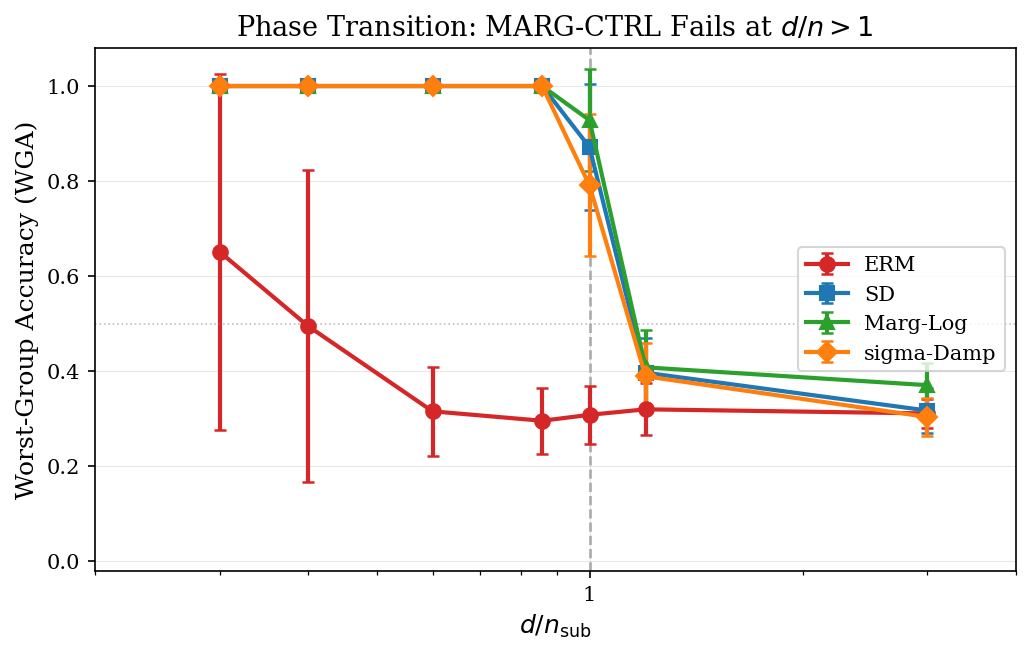

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
agg = df_e2.groupby(['ratio','method']).agg(wga_mean=('test_wga','mean'),wga_std=('test_wga','std')).reset_index()
agg['d_over_n'] = 300.0 / (agg['ratio'] * 1000)
for method in ['ERM', 'SD', 'Marg-Log', 'sigma-Damp']:
    sub = agg[agg['method']==method].sort_values('d_over_n')
    ax.errorbar(sub['d_over_n'], sub['wga_mean'], yerr=sub['wga_std'], label=method,
                color=COLORS[method], marker=MARKERS[method], markersize=7, linewidth=2, capsize=3, capthick=1.2)
add_phase_line(ax); ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xscale('log'); ax.set_xlabel(r'$d / n_{\mathrm{sub}}$'); ax.set_ylabel('Worst-Group Accuracy (WGA)')
ax.set_title('Phase Transition: MARG-CTRL Fails at $d/n > 1$')
ax.set_ylim(-0.02, 1.08); ax.set_xlim(0.2, 4.0)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}')); ax.legend(loc='center right')
fig.tight_layout(); save_fig(fig, 'fig1_phase_transition'); plt.show()

## Figure 2: Margin Analysis (E5)

  Saved fig2_margin_analysis.pdf and fig2_margin_analysis.png


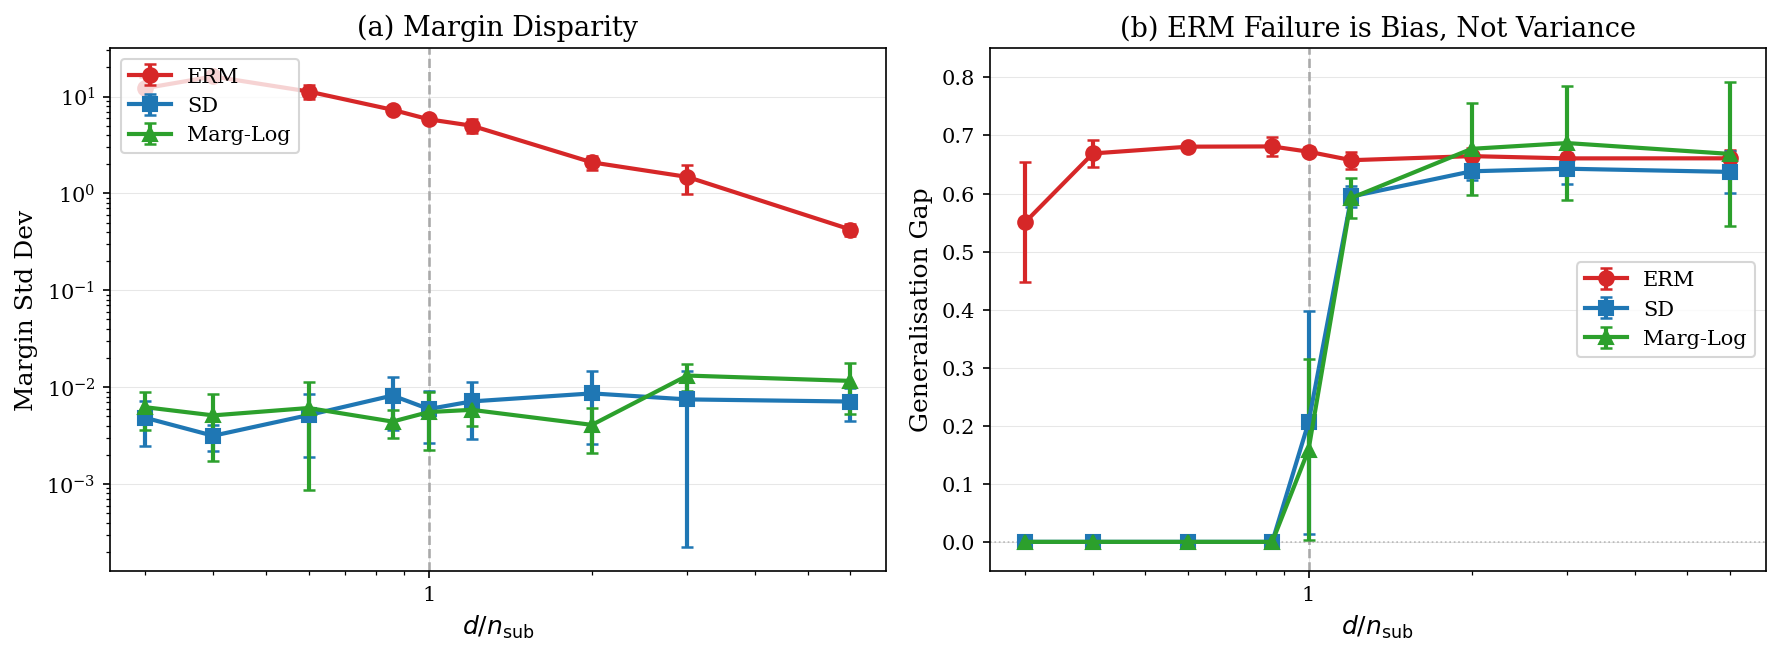

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
agg5 = df_e5.groupby(['ratio','method']).agg(
    wga_mean=('test_wga','mean'), gen_gap_mean=('gen_gap','mean'), gen_gap_std=('gen_gap','std'),
    margin_std_mean=('train_margin_std','mean'), margin_std_std=('train_margin_std','std')).reset_index()
agg5['d_over_n'] = 300.0 / (agg5['ratio'] * 1000)
for method in ['ERM', 'SD', 'Marg-Log']:
    sub = agg5[agg5['method']==method].sort_values('d_over_n')
    ax1.errorbar(sub['d_over_n'], sub['margin_std_mean'], yerr=sub['margin_std_std'], label=method,
                 color=COLORS[method], marker=MARKERS[method], markersize=7, linewidth=2, capsize=3, capthick=1.2)
    ax2.errorbar(sub['d_over_n'], sub['gen_gap_mean'], yerr=sub['gen_gap_std'], label=method,
                 color=COLORS[method], marker=MARKERS[method], markersize=7, linewidth=2, capsize=3, capthick=1.2)
for a in [ax1, ax2]: add_phase_line(a); a.set_xscale('log'); a.set_xlabel(r'$d / n_{\mathrm{sub}}$'); a.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax1.set_yscale('log'); ax1.set_ylabel('Margin Std Dev'); ax1.set_title('(a) Margin Disparity'); ax1.legend(loc='upper left')
ax2.axhline(y=0, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Generalisation Gap'); ax2.set_title('(b) ERM Failure is Bias, Not Variance'); ax2.set_ylim(-0.05, 0.85); ax2.legend(loc='center right')
fig.tight_layout(); save_fig(fig, 'fig2_margin_analysis'); plt.show()

## Figure 3: B-Invariance (E6)

  Saved fig3_B_invariance.pdf and fig3_B_invariance.png


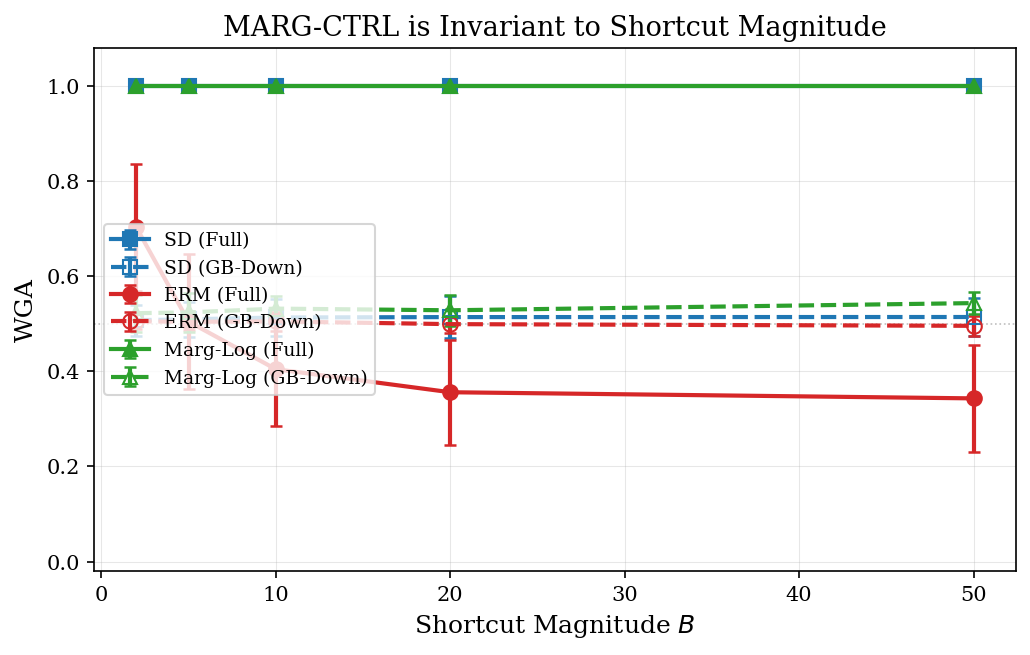

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
agg6 = df_e6.groupby(['B_experiment','condition','method']).agg(wga_mean=('test_wga','mean'),wga_std=('test_wga','std')).reset_index()
styles = {
    ('SD','Full'): dict(color=COLORS['SD'],linestyle='-',marker='s',label='SD (Full)'),
    ('SD','GB-Down'): dict(color=COLORS['SD'],linestyle='--',marker='s',label='SD (GB-Down)',markerfacecolor='none'),
    ('ERM','Full'): dict(color=COLORS['ERM'],linestyle='-',marker='o',label='ERM (Full)'),
    ('ERM','GB-Down'): dict(color=COLORS['ERM'],linestyle='--',marker='o',label='ERM (GB-Down)',markerfacecolor='none'),
    ('Marg-Log','Full'): dict(color=COLORS['Marg-Log'],linestyle='-',marker='^',label='Marg-Log (Full)'),
    ('Marg-Log','GB-Down'): dict(color=COLORS['Marg-Log'],linestyle='--',marker='^',label='Marg-Log (GB-Down)',markerfacecolor='none'),
}
for (method, cond), style in styles.items():
    sub = agg6[(agg6['method']==method)&(agg6['condition']==cond)].sort_values('B_experiment')
    if len(sub): ax.errorbar(sub['B_experiment'], sub['wga_mean'], yerr=sub['wga_std'], markersize=7, linewidth=2, capsize=3, capthick=1.2, **style)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Shortcut Magnitude $B$'); ax.set_ylabel('WGA'); ax.set_title('MARG-CTRL is Invariant to Shortcut Magnitude')
ax.set_ylim(-0.02, 1.08); ax.legend(loc='center left', fontsize=9)
fig.tight_layout(); save_fig(fig, 'fig3_B_invariance'); plt.show()

## Figure 4: Two-Shortcut Phase Transition (E7d)

  Saved fig4_two_shortcut_phase.pdf and fig4_two_shortcut_phase.png


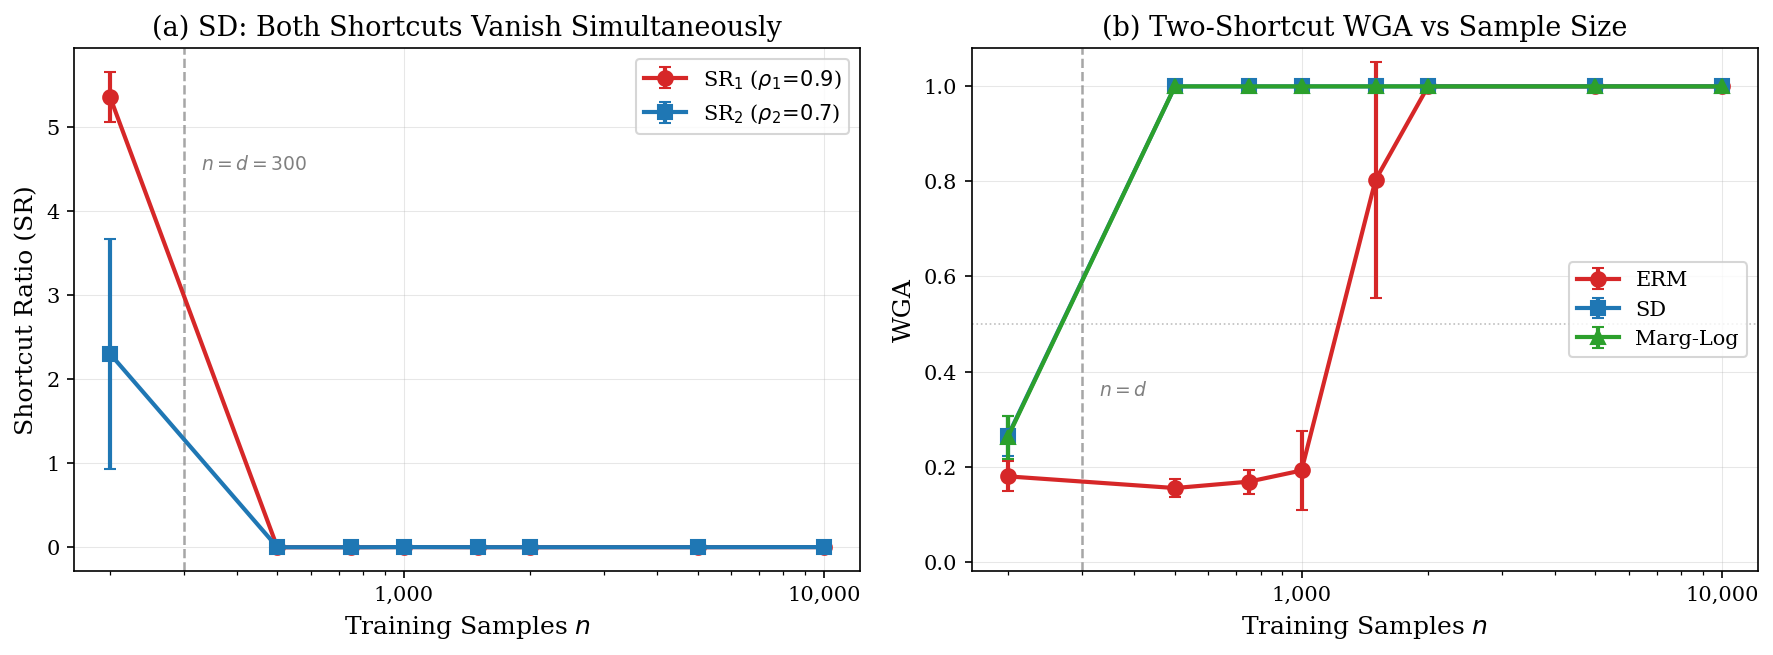

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
sd_7d = df_e7d[df_e7d['method']=='SD']
agg_sd = sd_7d.groupby('n_original').agg(SR1_mean=('SR1','mean'),SR1_std=('SR1','std'),SR2_mean=('SR2','mean'),SR2_std=('SR2','std'),wga_mean=('test_wga','mean'),wga_std=('test_wga','std')).reset_index()
ax1.errorbar(agg_sd['n_original'], agg_sd['SR1_mean'], yerr=agg_sd['SR1_std'], label=r'SR$_1$ ($\rho_1\!=\!0.9$)', color=COLORS['ERM'], marker='o', markersize=7, linewidth=2, capsize=3)
ax1.errorbar(agg_sd['n_original'], agg_sd['SR2_mean'], yerr=agg_sd['SR2_std'], label=r'SR$_2$ ($\rho_2\!=\!0.7$)', color=COLORS['SD'], marker='s', markersize=7, linewidth=2, capsize=3)
ax1.axvline(x=300, color='grey', linestyle='--', linewidth=1.2, alpha=0.7); ax1.text(330, 4.5, '$n=d=300$', fontsize=9, color='grey')
ax1.set_xscale('log'); ax1.set_xlabel('Training Samples $n$'); ax1.set_ylabel('Shortcut Ratio (SR)')
ax1.set_title('(a) SD: Both Shortcuts Vanish Simultaneously'); ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for method in ['ERM', 'SD', 'Marg-Log']:
    sub = df_e7d[df_e7d['method']==method].groupby('n_original').agg(wga_mean=('test_wga','mean'),wga_std=('test_wga','std')).reset_index()
    ax2.errorbar(sub['n_original'], sub['wga_mean'], yerr=sub['wga_std'], label=method, color=COLORS[method], marker=MARKERS[method], markersize=7, linewidth=2, capsize=3)
ax2.axvline(x=300, color='grey', linestyle='--', linewidth=1.2, alpha=0.7); ax2.text(330, 0.35, '$n=d$', fontsize=9, color='grey')
ax2.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.set_xscale('log'); ax2.set_xlabel('Training Samples $n$'); ax2.set_ylabel('WGA'); ax2.set_title('(b) Two-Shortcut WGA vs Sample Size')
ax2.set_ylim(-0.02, 1.08); ax2.legend(loc='center right'); ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.tight_layout(); save_fig(fig, 'fig4_two_shortcut_phase'); plt.show()

## Figure 5: GB-Down Across ρ (E3)

  Saved fig5_gb_down_rho.pdf and fig5_gb_down_rho.png


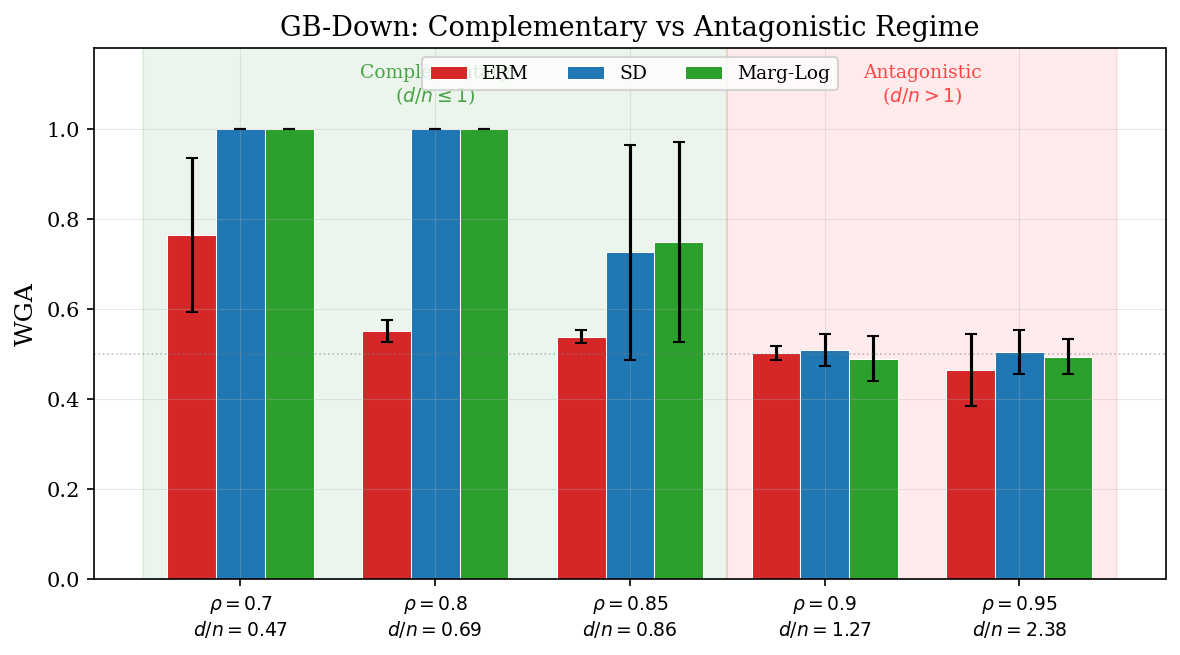

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
gb_only = df_e3[df_e3['condition']=='GB-Down'].copy()
agg3 = gb_only.groupby(['rho','method']).agg(wga_mean=('test_wga','mean'),wga_std=('test_wga','std'),d_over_n=('d_over_n','first')).reset_index()
rhos = sorted(agg3['rho'].unique()); x = np.arange(len(rhos)); width = 0.25
for i, method in enumerate(['ERM', 'SD', 'Marg-Log']):
    sub = agg3[agg3['method']==method].sort_values('rho')
    ax.bar(x + (i-1)*width, sub['wga_mean'], width, yerr=sub['wga_std'], label=method, color=COLORS[method], capsize=3, edgecolor='white', linewidth=0.5)
d_over_n_vals = agg3[agg3['method']=='ERM'].sort_values('rho')['d_over_n'].values
ax.set_xticks(x); ax.set_xticklabels([f'$\\rho={r}$\n$d/n={dn:.2f}$' for r, dn in zip(rhos, d_over_n_vals)], fontsize=9)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
# Shade: boundary between rho=0.85 (d/n=1.0) and rho=0.9 (d/n=1.5)
idx_085 = rhos.index(0.85) if 0.85 in rhos else 2
boundary = idx_085 + 0.5
ax.axvspan(-0.5, boundary, alpha=0.08, color='green', zorder=0)
ax.axvspan(boundary, len(rhos)-0.5, alpha=0.08, color='red', zorder=0)
ax.text((boundary-0.5)/2, 1.06, 'Complementary\n($d/n \\leq 1$)', fontsize=9, ha='center', color='green', alpha=0.7)
ax.text((boundary+len(rhos)-0.5)/2, 1.06, 'Antagonistic\n($d/n > 1$)', fontsize=9, ha='center', color='red', alpha=0.7)
ax.set_ylabel('WGA'); ax.set_title('GB-Down: Complementary vs Antagonistic Regime')
ax.set_ylim(0, 1.18); ax.legend(loc='upper center', ncol=3, fontsize=9)
fig.tight_layout(); save_fig(fig, 'fig5_gb_down_rho'); plt.show()

## Figure 6: Dataset Size Heatmap (E4)

  Saved fig6_size_heatmap.pdf and fig6_size_heatmap.png


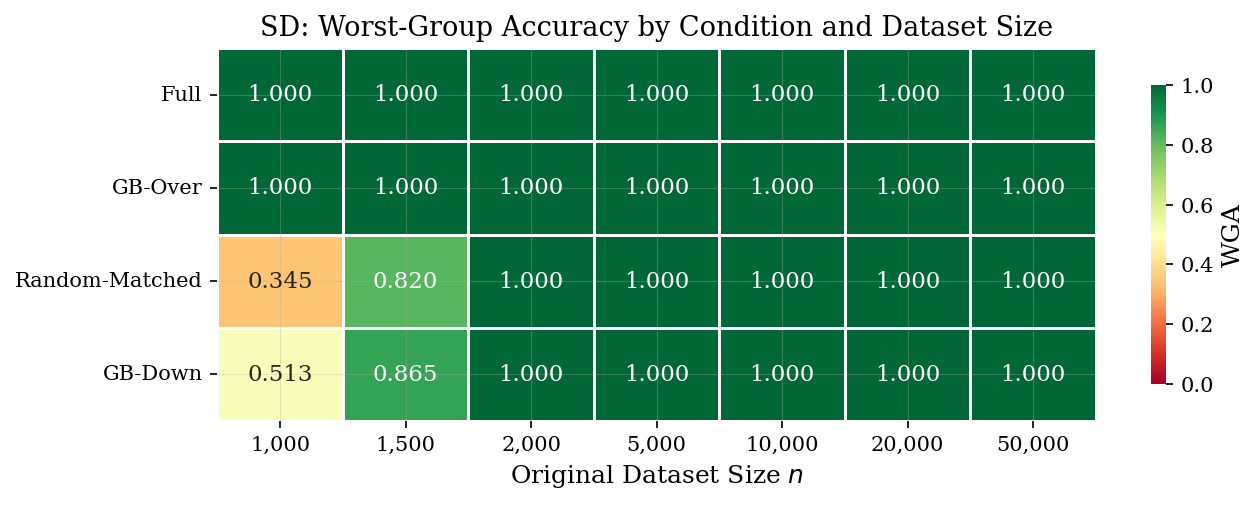

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))
pivot = df_e4[df_e4['method']=='SD'].groupby(['n_original','condition'])['test_wga'].mean().reset_index().pivot(index='condition', columns='n_original', values='test_wga')
pivot = pivot.reindex([r for r in ['Full','GB-Over','Random-Matched','GB-Down'] if r in pivot.index])
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'WGA', 'shrink': 0.8})
ax.set_xlabel('Original Dataset Size $n$'); ax.set_ylabel('')
ax.set_title('SD: Worst-Group Accuracy by Condition and Dataset Size')
ax.set_xticklabels([f'{int(float(c)):,}' for c in pivot.columns], rotation=0)
fig.tight_layout(); save_fig(fig, 'fig6_size_heatmap'); plt.show()

## Figure 7: Two-Shortcut Strategy Comparison (E7e)

  Saved fig7_two_shortcut_strategies.pdf and fig7_two_shortcut_strategies.png


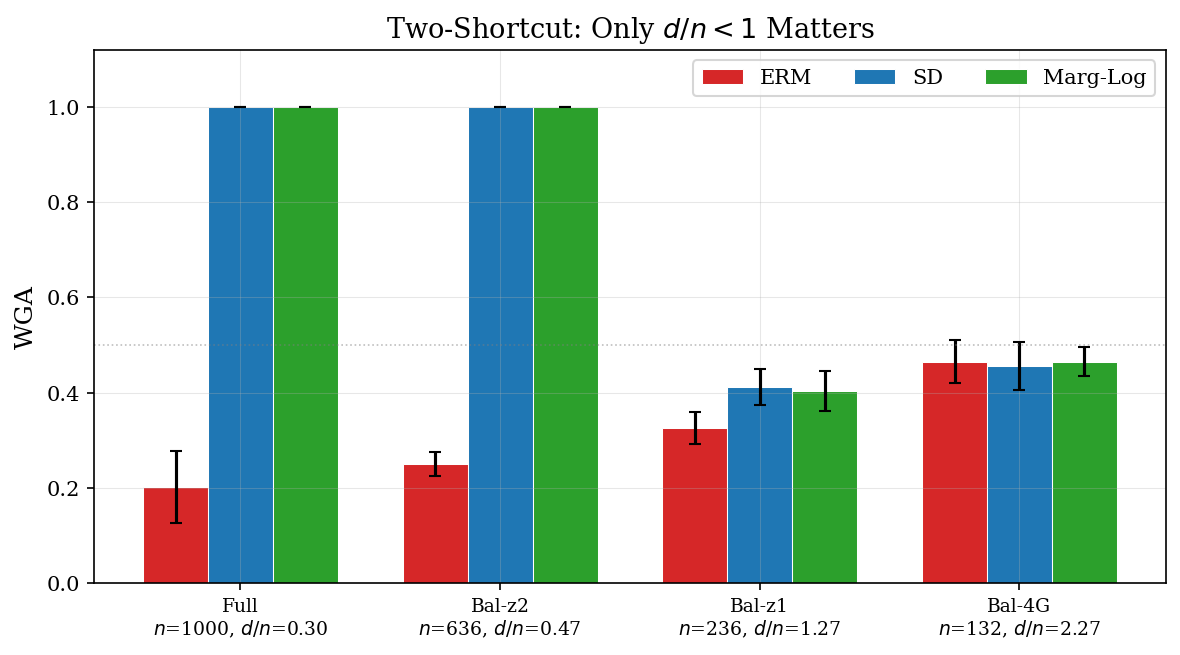

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
agg7e = df_e7e.groupby(['strategy','method']).agg(wga_mean=('test_wga','mean'),wga_std=('test_wga','std'),d_over_n=('d_over_n','first'),n_train=('n_train','first')).reset_index()
strategies = ['Full', 'Bal-z2', 'Bal-z1', 'Bal-4G']; x = np.arange(len(strategies)); width = 0.25
for i, method in enumerate(['ERM', 'SD', 'Marg-Log']):
    sub = agg7e[agg7e['method']==method]
    vals = [sub[sub['strategy']==s]['wga_mean'].values[0] if len(sub[sub['strategy']==s]) else 0 for s in strategies]
    errs = [sub[sub['strategy']==s]['wga_std'].values[0] if len(sub[sub['strategy']==s]) else 0 for s in strategies]
    ax.bar(x+(i-1)*width, vals, width, yerr=errs, label=method, color=COLORS[method], capsize=3, edgecolor='white', linewidth=0.5)
dn_vals = [agg7e[agg7e['strategy']==s]['d_over_n'].values[0] for s in strategies]
n_vals = [agg7e[agg7e['strategy']==s]['n_train'].values[0] for s in strategies]
ax.set_xticks(x); ax.set_xticklabels([f'{s}\n$n$={int(n)}, $d/n$={dn:.2f}' for s, n, dn in zip(strategies, n_vals, dn_vals)], fontsize=9)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_ylabel('WGA'); ax.set_title('Two-Shortcut: Only $d/n < 1$ Matters'); ax.set_ylim(0, 1.12); ax.legend(loc='upper right', ncol=3)
fig.tight_layout(); save_fig(fig, 'fig7_two_shortcut_strategies'); plt.show()

## Figure 8: Baseline Bar Chart (E1)

  Saved fig8_baseline.pdf and fig8_baseline.png


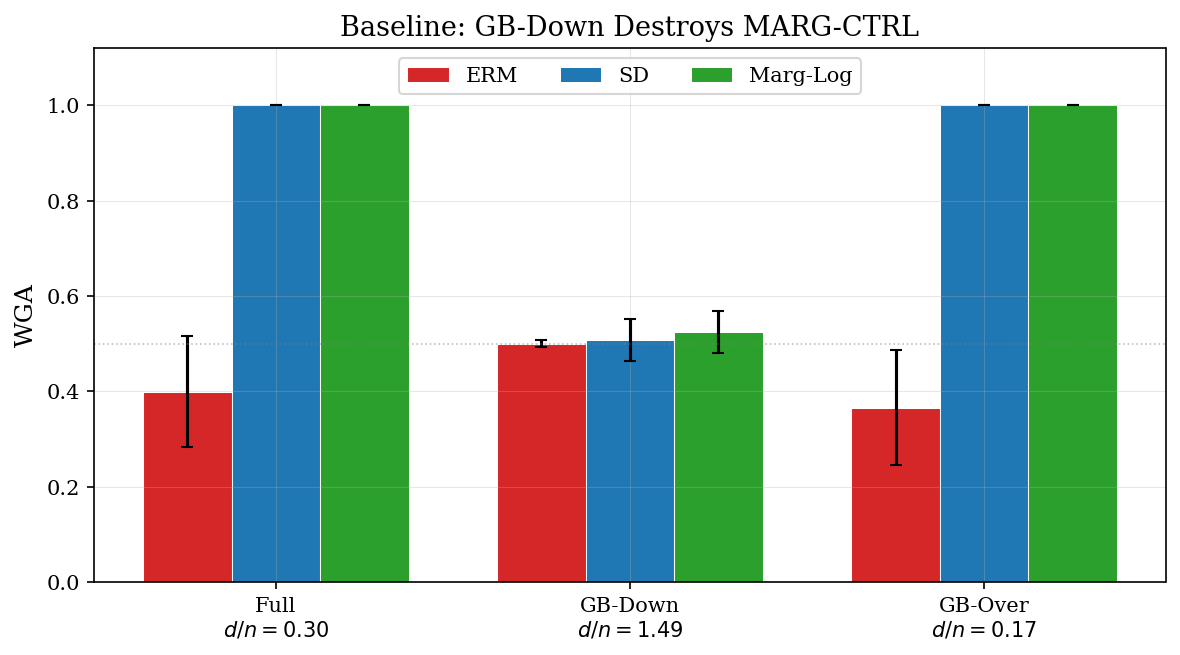

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
agg1 = df_e1.groupby(['condition','method']).agg(wga_mean=('test_wga','mean'),wga_std=('test_wga','std')).reset_index()
conditions = ['Full', 'GB-Down', 'GB-Over']; x = np.arange(len(conditions)); width = 0.25
for i, method in enumerate(['ERM', 'SD', 'Marg-Log']):
    sub = agg1[agg1['method']==method]
    vals = [sub[sub['condition']==c]['wga_mean'].values[0] for c in conditions]
    errs = [sub[sub['condition']==c]['wga_std'].values[0] for c in conditions]
    ax.bar(x+(i-1)*width, vals, width, yerr=errs, label=method, color=COLORS[method], capsize=3, edgecolor='white', linewidth=0.5)
dn_labels = {'Full': '$d/n = 0.30$', 'GB-Down': '$d/n = 1.49$', 'GB-Over': '$d/n = 0.17$'}
ax.set_xticks(x); ax.set_xticklabels([f'{c}\n{dn_labels[c]}' for c in conditions], fontsize=10)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_ylabel('WGA'); ax.set_title('Baseline: GB-Down Destroys MARG-CTRL'); ax.set_ylim(0, 1.12); ax.legend(loc='upper center', ncol=3)
fig.tight_layout(); save_fig(fig, 'fig8_baseline'); plt.show()

## Summary

In [ ]:
print('=' * 60)
print('ALL FIGURES GENERATED')
print('=' * 60)
print(f'\nSaved to: {SAVE_DIR}')
for f in sorted(SAVE_DIR.glob('fig*')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

ALL FIGURES GENERATED

Saved to: /content/drive/MyDrive/shortcut_experiments/figures
  fig1_phase_transition.pdf  (26.4 KB)
  fig1_phase_transition.png  (148.3 KB)
  fig2_margin_analysis.pdf  (31.1 KB)
  fig2_margin_analysis.png  (221.5 KB)
  fig3_B_invariance.pdf  (22.3 KB)
  fig3_B_invariance.png  (150.6 KB)
  fig4_two_shortcut_phase.pdf  (31.3 KB)
  fig4_two_shortcut_phase.png  (215.0 KB)
  fig5_gb_down_rho.pdf  (26.0 KB)
  fig5_gb_down_rho.png  (110.8 KB)
  fig6_size_heatmap.pdf  (22.5 KB)
  fig6_size_heatmap.png  (139.4 KB)
  fig7_two_shortcut_strategies.pdf  (21.9 KB)
  fig7_two_shortcut_strategies.png  (81.0 KB)
  fig8_baseline.pdf  (22.2 KB)
  fig8_baseline.png  (86.1 KB)


# TEMPORARY

In [ ]:
# ============================================================
# TEMPORARY CELL: Add n=300 (d/n=1.0) and n=400 (d/n=0.75) to E7d
# Run this AFTER the infrastructure cells (Cells 0-5 of the clean notebook).
# It appends to the existing CSV, then you can delete this cell.
# ============================================================

t0 = time.time()
print("Adding n=300 (d/n=1.00) and n=400 (d/n=0.75) to E7d...")

N_NEW = [300, 400]
SEEDS = list(range(3))
new_results = []

for n in N_NEW:
    results = run_two_shortcut_experiment(
        n_train=n,
        strategies={'Full': None},
        seeds=SEEDS,
    )
    new_results.extend(results)
    print(f"  n={n} done (d/n={D/n:.2f})")

df_new = pd.DataFrame(new_results)

# Append to existing CSV
existing_path = f'{DRIVE_ROOT}/csv/results_e7d_size_ablation.csv'
df_existing = pd.read_csv(existing_path)
common_cols = [c for c in df_existing.columns if c in df_new.columns]
df_combined = pd.concat([df_existing, df_new[common_cols]], ignore_index=True)
df_combined.to_csv(existing_path, index=False)

print(f"\nDone ({time.time()-t0:.0f}s). Appended {len(df_new)} rows.")
print(f"Total E7d rows: {len(df_combined)}")
print(f"\nSD results at new n values:")
sd = df_new[df_new['method'] == 'SD'].groupby('n_original').agg(
    d_over_n=('d_over_n', 'first'),
    SR1=('SR1', 'mean'), SR2=('SR2', 'mean'),
    wga=('test_wga', 'mean'),
).reset_index()
print(sd.to_string(index=False, float_format='{:.3f}'.format))
print("\n✓ You can now delete this cell and re-run the plotting cells.")

Adding n=300 (d/n=1.00) and n=400 (d/n=0.75) to E7d...
  n=300 done (d/n=1.00)
  n=400 done (d/n=0.75)

Done (48s). Appended 18 rows.
Total E7d rows: 90

SD results at new n values:
 n_original  d_over_n   SR1   SR2   wga
        300     1.000 0.223 0.137 0.716
        400     0.750 0.001 0.001 1.000

✓ You can now delete this cell and re-run the plotting cells.
